In [1]:
pip install netCDF4

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 116.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 153.0 MB/s eta 0:00:00


In [2]:
pip install eofs

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 21.5 MB/s eta 0:00:00


In [3]:
pip install pyshp

In [27]:
import netCDF4 as nc
import numpy as np
import matplotlib.pyplot as plt
import eofs
from eofs.standard import Eof
import shapefile
from datetime import datetime, timedelta
import datetime
from mpl_toolkits.axes_grid1 import make_axes_locatable  # Adicione esta linha para importar a função make_axes_locatable
from matplotlib.patches import Patch
import matplotlib.colors as colors
from matplotlib.colors import LinearSegmentedColormap


In [6]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [7]:
fn = '/content/drive/MyDrive/Colab Notebooks/ERA5/'


file_paths = ['era5_XXL_2003.nc', 'era5_XXL_2004.nc', 'era5_XXL_2005.nc', 'era5_XXL_2006.nc',
              'era5_XXL_2007.nc', 'era5_XXL_2008.nc', 'era5_XXL_2009.nc', 'era5_XXL_2010.nc',
              'era5_XXL_2011.nc', 'era5_XXL_2012.nc', 'era5_XXL_2013.nc', 'era5_XXL_2014.nc',
              'era5_XXL_2015.nc', 'era5_XXL_2016.nc', 'era5_XXL_2017.nc', 'era5_XXL_2018.nc',
              'era5_XXL_2019.nc' ,'era5_XXL_2020.nc', 'era5_XXL_2021.nc',
              'era5_XXL_2022.nc',
              'era5_XXL_2023.nc']

ds = [nc.Dataset(fn+file_path, 'r') for file_path in file_paths]
ds_mask = nc.Dataset(fn+'era5_landseamask.nc', 'r')


In [8]:
# Concatenar os datasets ao longo da dimensão de tempo
lat0 = ds[0]['latitude']
lon0 = ds[0]['longitude']
time = np.concatenate([ds[i]['time'][:] for i in range(len(ds))])
u = np.concatenate([ds[i]['u10'][:] for i in range(len(ds))])
v = np.concatenate([ds[i]['v10'][:] for i in range(len(ds))])
base_date = datetime.datetime(1900, 1, 1, 0, 0, 0)
time_datetime = [base_date + timedelta(hours=int(t)) for t in time]

In [ ]:
#44 - 52
#lon0[44]
#37 - 32.25
#lat0[37]

In [9]:
u_eventos = u[:, 37, 44]
v_eventos = v[:, 37, 44]

M = np.sqrt(u_eventos**2 + v_eventos**2)
UV_dir = np.arctan2(v_eventos/M, u_eventos/M)
UV_dir_degrees = np.rad2deg(UV_dir)
UV_dir_degrees[UV_dir_degrees < 0] += 360

UV_dir_degrees = (450 - UV_dir_degrees) % 360

In [10]:
np.min(UV_dir_degrees[183270:183281]), np.max(UV_dir_degrees[183270:183281]), np.nanmean(UV_dir_degrees[183270:183281])

(np.float64(238.1880487215329),
 np.float64(245.6180199997639),
 np.float64(242.7656221338494))

In [11]:
NE_time = np.zeros(len(time))
NE_dir = np.zeros(len(time))
NE_u = np.zeros(len(time))
NE_v = np.zeros(len(time))
NE_m = np.zeros(len(time))

#mask = (187 <= UV_dir_degrees) & (UV_dir_degrees <= 227) & (M >= 8)
mask = (222 <= UV_dir_degrees) & (UV_dir_degrees <= 262) & (M >= 8)
#mask = (64 <= UV_dir_degrees) & (UV_dir_degrees <= 80) & (M >= 8.6)
#mask_mag = (M >= 8.6)

NE_time[mask] = time[mask]
NE_dir[mask] = UV_dir_degrees[mask]
NE_u[mask] = u_eventos[mask]
NE_v[mask] = v_eventos[mask]
NE_m[mask] = M[mask]

NE_time[~mask] = np.nan
NE_dir[~mask] = np.nan
NE_u[~mask] = np.nan
NE_v[~mask] = np.nan
NE_m[~mask] = np.nan

(-54.0, -48.0)

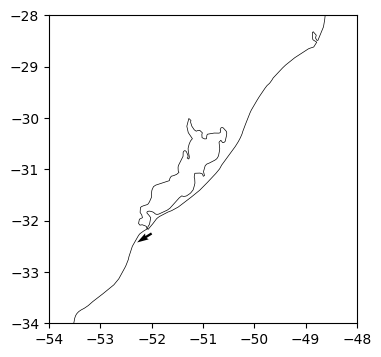

In [12]:
fig, ax = plt.subplots(figsize=(4, 4), dpi=100)
divider = make_axes_locatable(ax)

sf = shapefile.Reader('/content/drive/MyDrive/Colab Notebooks/ERA5/SouthAmerica_coastline_line_degdec.shp')

# Obter os registros do shapefile
records = sf.records()


# Obter os polígonos do shapefile
shapes = sf.shapes()

# Plotar os polígonos
for shape in shapes:
    x, y = zip(*shape.points)
    ax.plot(x, y, color ='k', linewidth = 0.5)



ax.quiver(lon0[44], lat0[37], NE_u[183270], NE_v[183270])
ax.axis('equal')
ax.set_ylim([-34, -28])
ax.set_xlim([-54, -48])

In [13]:
duracao_eventos = []
intensidade_eventos = []
tempo_eventos = []
em_evento = False

inicio_evento = None

for i, valor in enumerate(mask):
    if valor and not em_evento:
        inicio_evento = NE_time[i]
        idx_evento = i
        em_evento = True
    elif not valor and em_evento:
        duracao_evento = NE_time[i - 1] - inicio_evento
        em_evento = False
        if duracao_evento > 0:
            duracao_eventos.append(duracao_evento)
            intensidade_evento = np.nanmean(NE_m[idx_evento:i-1])
            intensidade_eventos.append(intensidade_evento)
            tempo_eventos.append(base_date + timedelta(hours=int(inicio_evento)))
duracao_eventos = np.array([duracao_eventos]).squeeze()


In [14]:
mes_intensidade = []
mes_duracao = []


for i in range(12):
    g = []
    h = []
    for j, t in enumerate(tempo_eventos):
        if t.month == i+1:
            g.append(intensidade_eventos[j])
            h.append(duracao_eventos[j])
    g = np.array(g)
    mes_intensidade.append(g)
    mes_duracao.append(h)

Text(9.5, 13.5, 'Wind Speed > 8 m/s')

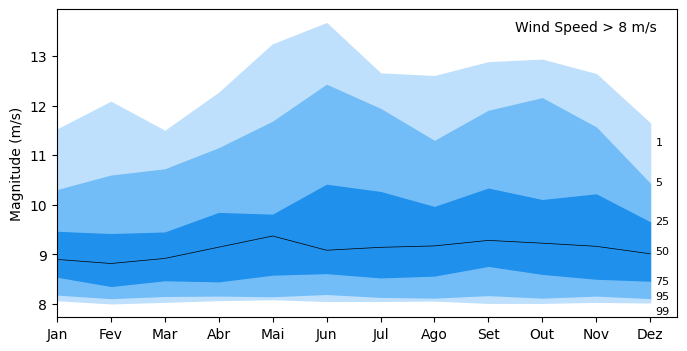

In [15]:
mes_guarda01 = []
mes_guarda05 = []
mes_guarda25 = []
mes_guarda50 = []
mes_guarda75 = []
mes_guarda95 = []
mes_guarda99 = []

for i in range(12):
  cpx = np.linspace(0,1, len(mes_intensidade[i]))
  cpy = np.sort(mes_intensidade[i])

  guarda01 = np.interp(0.01,cpx,cpy)
  guarda05 = np.interp(0.05,cpx,cpy)
  guarda25 = np.interp(0.25,cpx,cpy)
  guarda50 = np.interp(0.50,cpx,cpy)
  guarda75 = np.interp(0.75,cpx,cpy)
  guarda95 = np.interp(0.95,cpx,cpy)
  guarda99 = np.interp(0.99,cpx,cpy)

  mes_guarda01.append(guarda01)
  mes_guarda05.append(guarda05)
  mes_guarda25.append(guarda25)
  mes_guarda50.append(guarda50)
  mes_guarda75.append(guarda75)
  mes_guarda95.append(guarda95)
  mes_guarda99.append(guarda99)

meses = np.arange(1,13)
meses_label = ['Jan', 'Fev', 'Mar', 'Abr', 'Mai', 'Jun', 'Jul', 'Ago', 'Set', 'Out', 'Nov', 'Dez']

fig, ax = plt.subplots(figsize=(8,4), dpi = 100)



ax.fill_between(meses, mes_guarda99, mes_guarda95, color = '#bfe0fc')
ax.fill_between(meses, mes_guarda95, mes_guarda75, color = '#72bdf7')
ax.fill_between(meses, mes_guarda25, mes_guarda75, color = '#1f90ec')
ax.fill_between(meses, mes_guarda25, mes_guarda05, color = '#72bdf7')
ax.fill_between(meses, mes_guarda05, mes_guarda01, color = '#bfe0fc')
ax.plot(meses, mes_guarda50, linewidth=0.5 , color ='k')
ax.annotate(1, xy = (12.1, 11.2), fontsize = 8)
ax.annotate(5, xy = (12.1, 10.4), fontsize = 8)
ax.annotate(25, xy = (12.1, 9.6), fontsize = 8)
ax.annotate(50, xy = (12.1, 9), fontsize = 8)
ax.annotate(75, xy = (12.1, 8.4), fontsize = 8)
ax.annotate(95, xy = (12.1, 8.1), fontsize = 8)
ax.annotate(99, xy = (12.1, 7.8), fontsize = 8)

ax.set_xlim(1, 12.5)
ax.set_xticks(meses)
ax.set_xticklabels(meses_label)
ax.set_ylabel('Magnitude (m/s)')
ax.annotate('Wind Speed > 8 m/s', xy = (9.5, 13.5))


Text(9, 74, 'Wind Speed > 8 m/s')

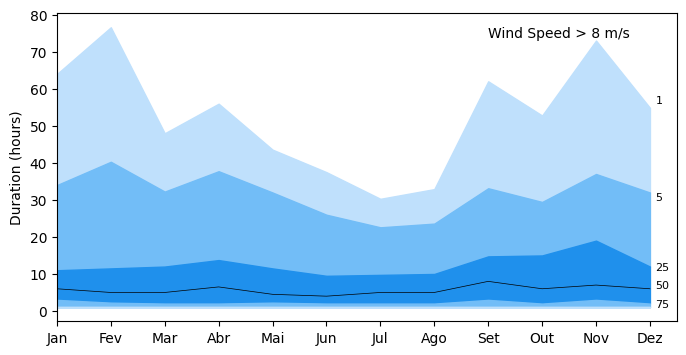

In [16]:
mes_guarda01 = []
mes_guarda05 = []
mes_guarda25 = []
mes_guarda50 = []
mes_guarda75 = []
mes_guarda95 = []
mes_guarda99 = []

for i in range(12):
  cpx = np.linspace(0,1, len(mes_duracao[i]))
  cpy = np.sort(mes_duracao[i])

  guarda01 = np.interp(0.01,cpx,cpy)
  guarda05 = np.interp(0.05,cpx,cpy)
  guarda25 = np.interp(0.25,cpx,cpy)
  guarda50 = np.interp(0.50,cpx,cpy)
  guarda75 = np.interp(0.75,cpx,cpy)
  guarda95 = np.interp(0.95,cpx,cpy)
  guarda99 = np.interp(0.99,cpx,cpy)

  mes_guarda01.append(guarda01)
  mes_guarda05.append(guarda05)
  mes_guarda25.append(guarda25)
  mes_guarda50.append(guarda50)
  mes_guarda75.append(guarda75)
  mes_guarda95.append(guarda95)
  mes_guarda99.append(guarda99)

meses = np.arange(1,13)
meses_label = ['Jan', 'Fev', 'Mar', 'Abr', 'Mai', 'Jun', 'Jul', 'Ago', 'Set', 'Out', 'Nov', 'Dez']

fig, ax = plt.subplots(figsize=(8,4), dpi = 100)



ax.fill_between(meses, mes_guarda99, mes_guarda95, color = '#bfe0fc')
ax.fill_between(meses, mes_guarda95, mes_guarda75, color = '#72bdf7')
ax.fill_between(meses, mes_guarda25, mes_guarda75, color = '#1f90ec')
ax.fill_between(meses, mes_guarda25, mes_guarda05, color = '#72bdf7')
ax.fill_between(meses, mes_guarda05, mes_guarda01, color = '#bfe0fc')
ax.plot(meses, mes_guarda50, linewidth=0.5 , color ='k')
ax.annotate(1, xy = (12.1, 56), fontsize = 8)
ax.annotate(5, xy = (12.1, 30), fontsize = 8)
ax.annotate(25, xy = (12.1, 11), fontsize = 8)
ax.annotate(50, xy = (12.1, 6), fontsize = 8)
ax.annotate(75, xy = (12.1, 1), fontsize = 8)
#ax.annotate(95, xy = (12.1, 0.5), fontsize = 8)
#ax.annotate(99, xy = (12.1, 8.2), fontsize = 8)

ax.set_xlim(1, 12.5)
ax.set_xticks(meses)
ax.set_xticklabels(meses_label)
ax.set_ylabel('Duration (hours)')
ax.annotate('Wind Speed > 8 m/s', xy = (9, 74))



In [17]:
NE_time = np.zeros(len(time))
NE_dir = np.zeros(len(time))
NE_u = np.zeros(len(time))
NE_v = np.zeros(len(time))
NE_m = np.zeros(len(time))

#mask = (187 <= UV_dir_degrees) & (UV_dir_degrees <= 227) & (M >= 8)
mask = (222 <= UV_dir_degrees) & (UV_dir_degrees <= 262) & (M > 0)
#mask = (64 <= UV_dir_degrees) & (UV_dir_degrees <= 80) & (M >= 8.6)
#mask_mag = (M >= 8.6)

NE_time[mask] = time[mask]
NE_dir[mask] = UV_dir_degrees[mask]
NE_u[mask] = u_eventos[mask]
NE_v[mask] = v_eventos[mask]
NE_m[mask] = M[mask]

NE_time[~mask] = np.nan
NE_dir[~mask] = np.nan
NE_u[~mask] = np.nan
NE_v[~mask] = np.nan
NE_m[~mask] = np.nan

In [18]:
duracao_eventos = []
intensidade_eventos = []
tempo_eventos = []
em_evento = False

inicio_evento = None

for i, valor in enumerate(mask):
    if valor and not em_evento:
        inicio_evento = NE_time[i]
        idx_evento = i
        em_evento = True
    elif not valor and em_evento:
        duracao_evento = NE_time[i - 1] - inicio_evento
        em_evento = False
        if duracao_evento > 0:
            duracao_eventos.append(duracao_evento)
            intensidade_evento = np.nanmean(NE_m[idx_evento:i-1])
            intensidade_eventos.append(intensidade_evento)
            tempo_eventos.append(base_date + timedelta(hours=int(inicio_evento)))
duracao_eventos = np.array([duracao_eventos]).squeeze()


In [19]:
mes_intensidade = []
mes_duracao = []


for i in range(12):
    g = []
    h = []
    for j, t in enumerate(tempo_eventos):
        if t.month == i+1:
            g.append(intensidade_eventos[j])
            h.append(duracao_eventos[j])
    g = np.array(g)
    mes_intensidade.append(g)
    mes_duracao.append(h)

Text(1.3, 12.5, 'Wind Speed > 0 m/s')

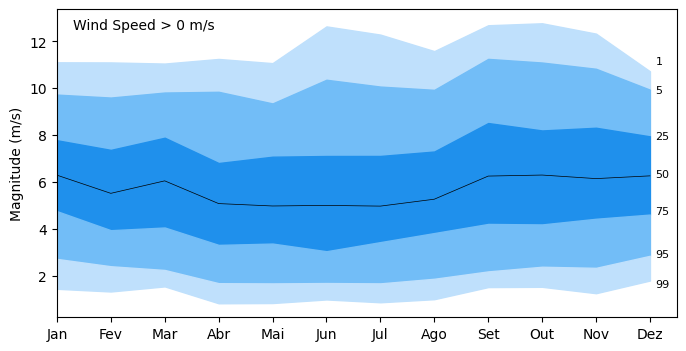

In [20]:
mes_guarda01 = []
mes_guarda05 = []
mes_guarda25 = []
mes_guarda50 = []
mes_guarda75 = []
mes_guarda95 = []
mes_guarda99 = []

for i in range(12):
  cpx = np.linspace(0,1, len(mes_intensidade[i]))
  cpy = np.sort(mes_intensidade[i])

  guarda01 = np.interp(0.01,cpx,cpy)
  guarda05 = np.interp(0.05,cpx,cpy)
  guarda25 = np.interp(0.25,cpx,cpy)
  guarda50 = np.interp(0.50,cpx,cpy)
  guarda75 = np.interp(0.75,cpx,cpy)
  guarda95 = np.interp(0.95,cpx,cpy)
  guarda99 = np.interp(0.99,cpx,cpy)

  mes_guarda01.append(guarda01)
  mes_guarda05.append(guarda05)
  mes_guarda25.append(guarda25)
  mes_guarda50.append(guarda50)
  mes_guarda75.append(guarda75)
  mes_guarda95.append(guarda95)
  mes_guarda99.append(guarda99)

meses = np.arange(1,13)
meses_label = ['Jan', 'Fev', 'Mar', 'Abr', 'Mai', 'Jun', 'Jul', 'Ago', 'Set', 'Out', 'Nov', 'Dez']

fig, ax = plt.subplots(figsize=(8,4), dpi = 100)



ax.fill_between(meses, mes_guarda99, mes_guarda95, color = '#bfe0fc')
ax.fill_between(meses, mes_guarda95, mes_guarda75, color = '#72bdf7')
ax.fill_between(meses, mes_guarda25, mes_guarda75, color = '#1f90ec')
ax.fill_between(meses, mes_guarda25, mes_guarda05, color = '#72bdf7')
ax.fill_between(meses, mes_guarda05, mes_guarda01, color = '#bfe0fc')
ax.plot(meses, mes_guarda50, linewidth=0.5 , color ='k')
ax.annotate(1, xy = (12.1, 11), fontsize = 8)
ax.annotate(5, xy = (12.1, 9.8), fontsize = 8)
ax.annotate(25, xy = (12.1, 7.8), fontsize = 8)
ax.annotate(50, xy = (12.1, 6.2), fontsize = 8)
ax.annotate(75, xy = (12.1, 4.6), fontsize = 8)
ax.annotate(95, xy = (12.1, 2.8), fontsize = 8)
ax.annotate(99, xy = (12.1, 1.5), fontsize = 8)

ax.set_xlim(1, 12.5)
ax.set_xticks(meses)
ax.set_xticklabels(meses_label)
ax.set_ylabel('Magnitude (m/s)')
ax.annotate('Wind Speed > 0 m/s', xy = (1.3, 12.5))


Text(1.3, 85, 'Wind Speed > 0 m/s')

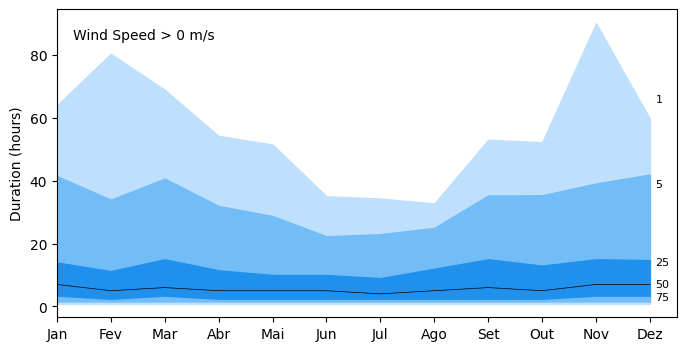

In [ ]:
mes_guarda01 = []
mes_guarda05 = []
mes_guarda25 = []
mes_guarda50 = []
mes_guarda75 = []
mes_guarda95 = []
mes_guarda99 = []

for i in range(12):
  cpx = np.linspace(0,1, len(mes_duracao[i]))
  cpy = np.sort(mes_duracao[i])

  guarda01 = np.interp(0.01,cpx,cpy)
  guarda05 = np.interp(0.05,cpx,cpy)
  guarda25 = np.interp(0.25,cpx,cpy)
  guarda50 = np.interp(0.50,cpx,cpy)
  guarda75 = np.interp(0.75,cpx,cpy)
  guarda95 = np.interp(0.95,cpx,cpy)
  guarda99 = np.interp(0.99,cpx,cpy)

  mes_guarda01.append(guarda01)
  mes_guarda05.append(guarda05)
  mes_guarda25.append(guarda25)
  mes_guarda50.append(guarda50)
  mes_guarda75.append(guarda75)
  mes_guarda95.append(guarda95)
  mes_guarda99.append(guarda99)

meses = np.arange(1,13)
meses_label = ['Jan', 'Fev', 'Mar', 'Abr', 'Mai', 'Jun', 'Jul', 'Ago', 'Set', 'Out', 'Nov', 'Dez']

fig, ax = plt.subplots(figsize=(8,4), dpi = 100)



ax.fill_between(meses, mes_guarda99, mes_guarda95, color = '#bfe0fc')
ax.fill_between(meses, mes_guarda95, mes_guarda75, color = '#72bdf7')
ax.fill_between(meses, mes_guarda25, mes_guarda75, color = '#1f90ec')
ax.fill_between(meses, mes_guarda25, mes_guarda05, color = '#72bdf7')
ax.fill_between(meses, mes_guarda05, mes_guarda01, color = '#bfe0fc')
ax.plot(meses, mes_guarda50, linewidth=0.5 , color ='k')
ax.annotate(1, xy = (12.1, 65), fontsize = 8)
ax.annotate(5, xy = (12.1, 38), fontsize = 8)
ax.annotate(25, xy = (12.1, 13), fontsize = 8)
ax.annotate(50, xy = (12.1, 6), fontsize = 8)
ax.annotate(75, xy = (12.1, 2), fontsize = 8)
#ax.annotate(95, xy = (12.1, 0), fontsize = 8)
#ax.annotate(99, xy = (12.1, 8.2), fontsize = 8)

ax.set_xlim(1, 12.5)
ax.set_xticks(meses)
ax.set_xticklabels(meses_label)
ax.set_ylabel('Duration (hours)')
ax.annotate('Wind Speed > 0 m/s', xy = (1.3, 85))



13.657811120183844 8.09122103746036


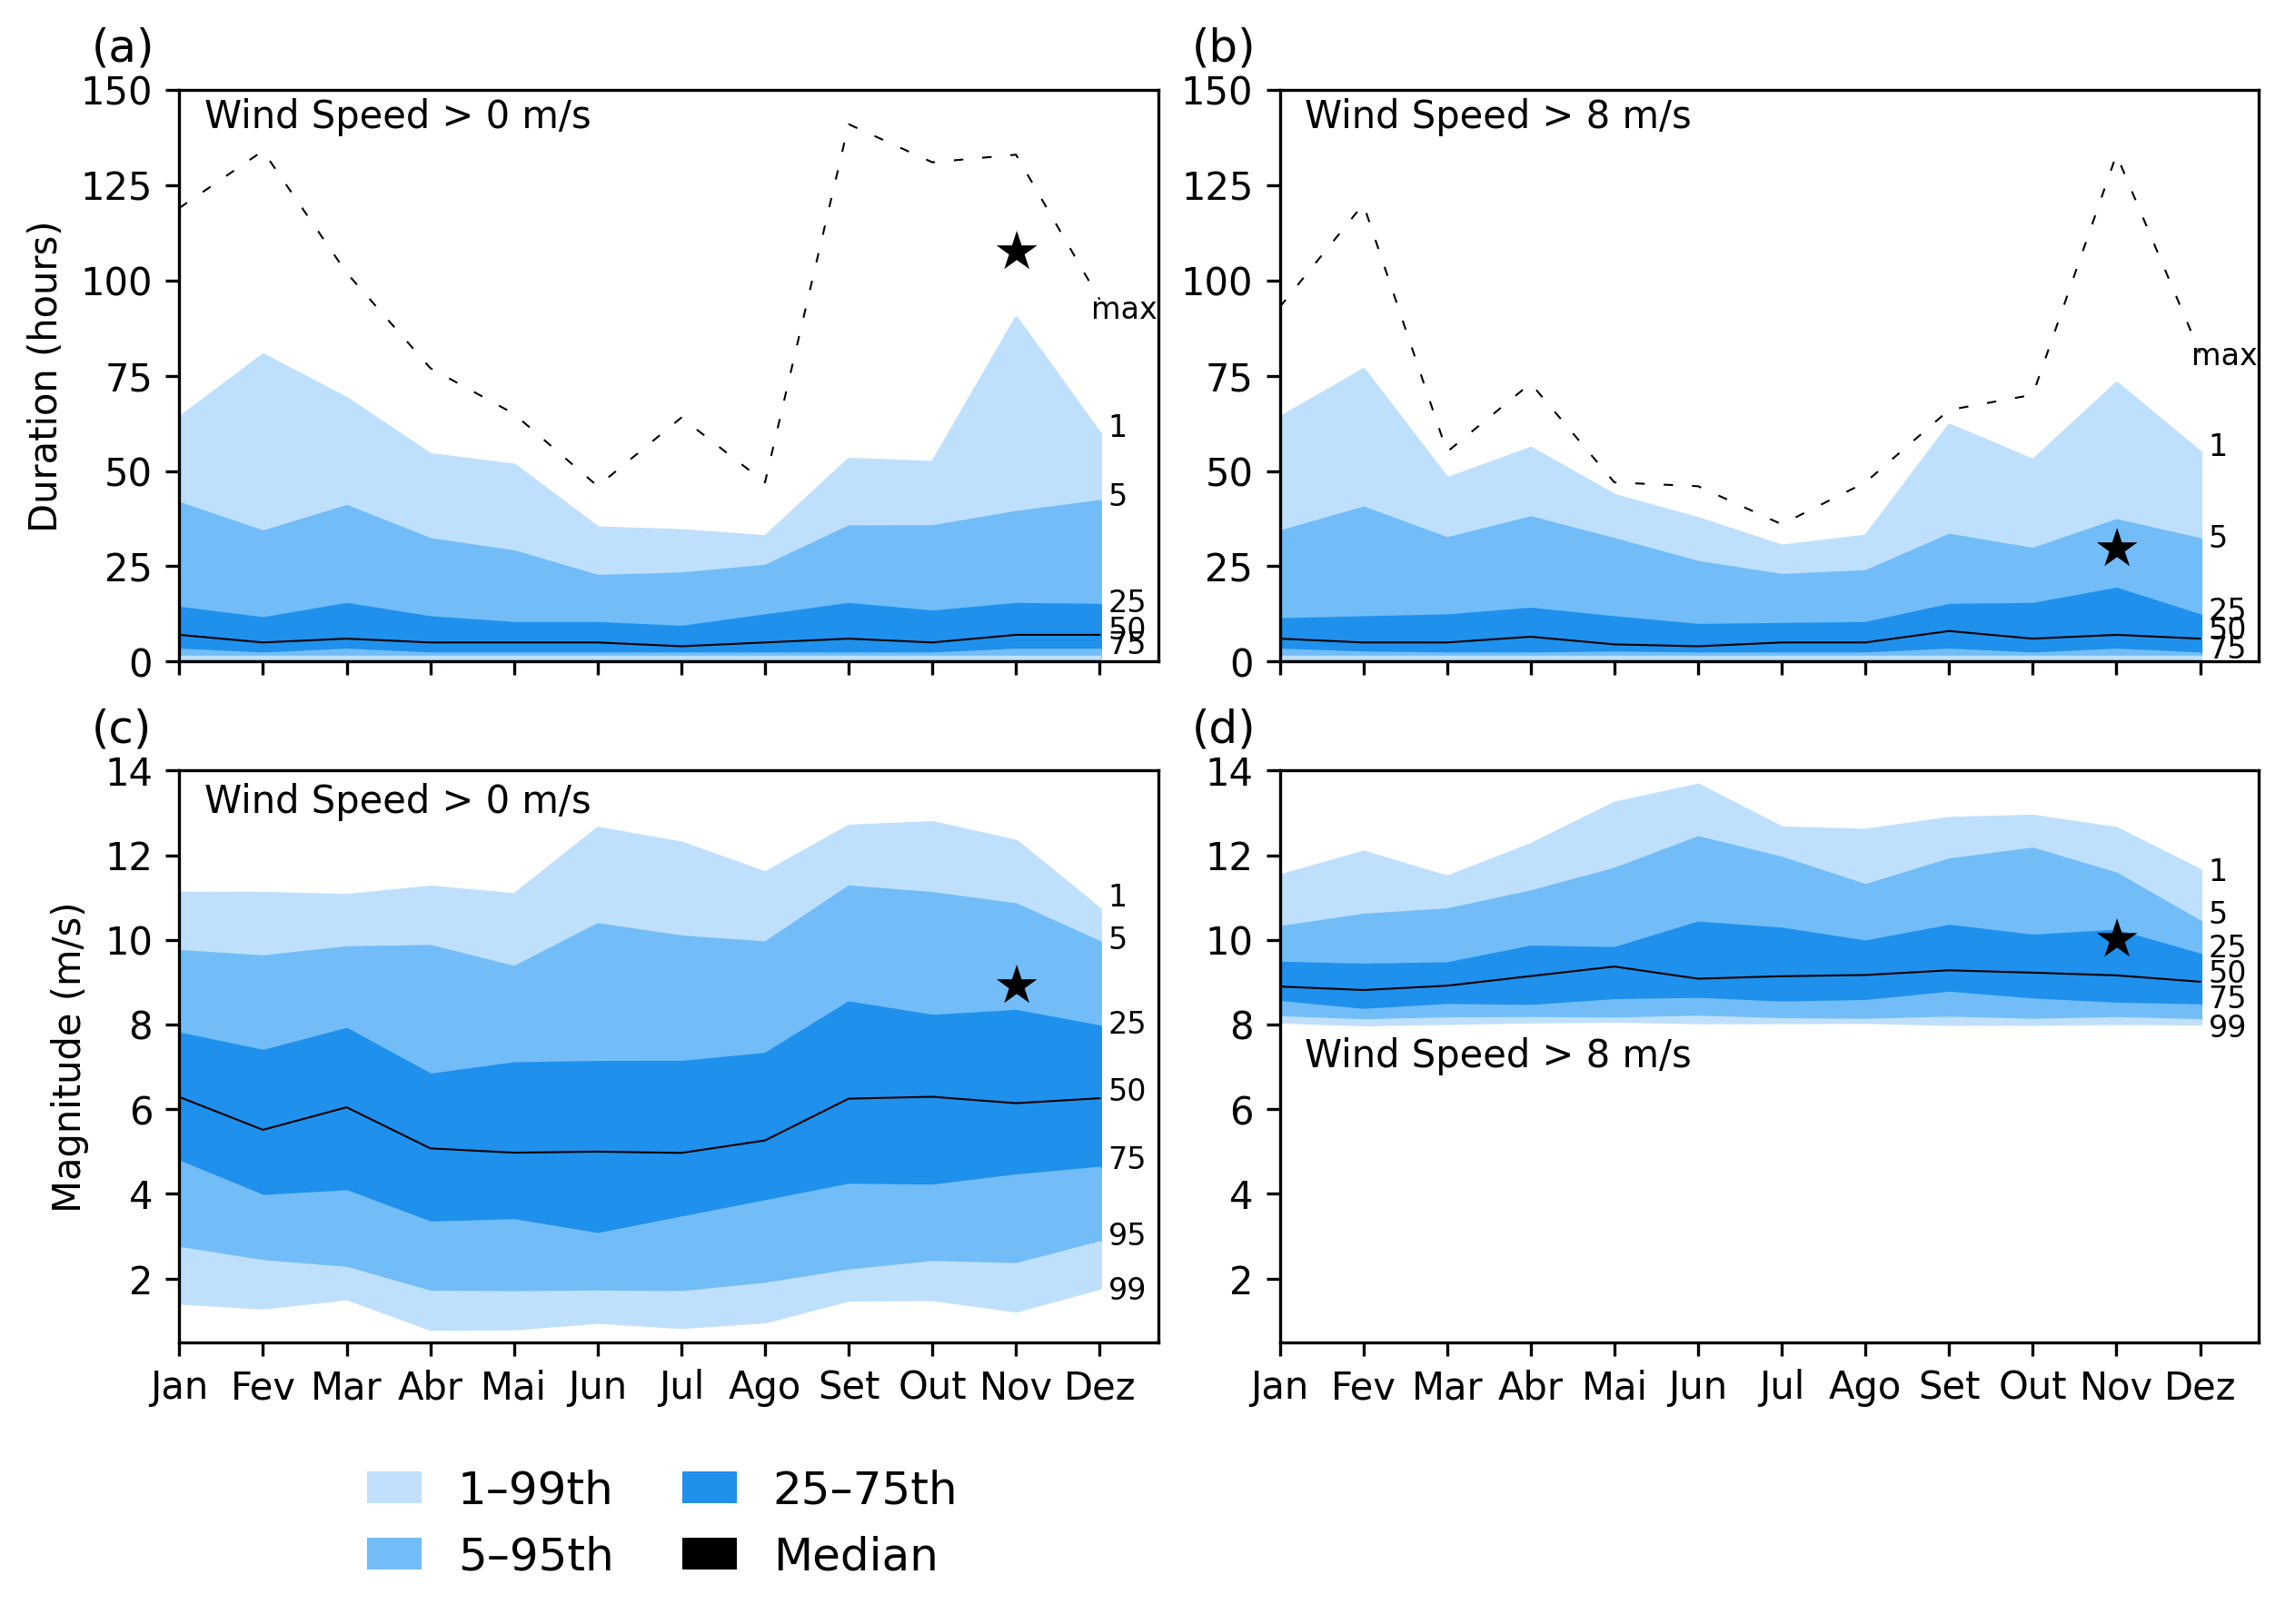

In [41]:
fig, ax = plt.subplots(2,2, figsize=(8.27, 5.845), dpi = 300, constrained_layout = True)



NE_time = np.zeros(len(time))
NE_dir = np.zeros(len(time))
NE_u = np.zeros(len(time))
NE_v = np.zeros(len(time))
NE_m = np.zeros(len(time))

mask = (222 <= UV_dir_degrees) & (UV_dir_degrees <= 262) & (M >= 8)


NE_time[mask] = time[mask]
NE_dir[mask] = UV_dir_degrees[mask]
NE_u[mask] = u_eventos[mask]
NE_v[mask] = v_eventos[mask]
NE_m[mask] = M[mask]

NE_time[~mask] = np.nan
NE_dir[~mask] = np.nan
NE_u[~mask] = np.nan
NE_v[~mask] = np.nan
NE_m[~mask] = np.nan


duracao_eventos = []
intensidade_eventos = []
tempo_eventos = []
em_evento = False

inicio_evento = None

for i, valor in enumerate(mask):
    if valor and not em_evento:
        inicio_evento = NE_time[i]
        idx_evento = i
        em_evento = True
    elif not valor and em_evento:
        duracao_evento = NE_time[i - 1] - inicio_evento
        em_evento = False
        if duracao_evento > 0:
            duracao_eventos.append(duracao_evento)
            intensidade_evento = np.nanmean(NE_m[idx_evento:i-1])
            intensidade_eventos.append(intensidade_evento)
            tempo_eventos.append(base_date + timedelta(hours=int(inicio_evento)))
duracao_eventos = np.array([duracao_eventos]).squeeze()


mes_intensidade = []
mes_duracao = []


for i in range(12):
    g = []
    h = []
    for j, t in enumerate(tempo_eventos):
        if t.month == i+1:
            g.append(intensidade_eventos[j])
            h.append(duracao_eventos[j])
    g = np.array(g)
    mes_intensidade.append(g)
    mes_duracao.append(h)

mes_guarda01 = []
mes_guarda05 = []
mes_guarda25 = []
mes_guarda50 = []
mes_guarda75 = []
mes_guarda95 = []
mes_guarda99 = []

for i in range(12):
  cpx = np.linspace(0,1, len(mes_intensidade[i]))
  cpy = np.sort(mes_intensidade[i])

  guarda01 = np.interp(0.01,cpx,cpy)
  guarda05 = np.interp(0.05,cpx,cpy)
  guarda25 = np.interp(0.25,cpx,cpy)
  guarda50 = np.interp(0.50,cpx,cpy)
  guarda75 = np.interp(0.75,cpx,cpy)
  guarda95 = np.interp(0.95,cpx,cpy)
  guarda99 = np.interp(0.99,cpx,cpy)

  mes_guarda01.append(guarda01)
  mes_guarda05.append(guarda05)
  mes_guarda25.append(guarda25)
  mes_guarda50.append(guarda50)
  mes_guarda75.append(guarda75)
  mes_guarda95.append(guarda95)
  mes_guarda99.append(guarda99)

meses = np.arange(1,13)
meses_label = ['Jan', 'Fev', 'Mar', 'Abr', 'Mai', 'Jun', 'Jul', 'Ago', 'Set', 'Out', 'Nov', 'Dez']

print(np.max(mes_guarda99), np.min(mes_guarda05))

ax[1, 1].fill_between(meses, mes_guarda99, mes_guarda95, color = '#bfe0fc')
ax[1, 1].fill_between(meses, mes_guarda95, mes_guarda75, color = '#72bdf7')
ax[1, 1].fill_between(meses, mes_guarda25, mes_guarda75, color = '#1f90ec')
ax[1, 1].fill_between(meses, mes_guarda25, mes_guarda05, color = '#72bdf7')
ax[1, 1].fill_between(meses, mes_guarda05, mes_guarda01, color = '#bfe0fc')
ax[1, 1].plot(meses, mes_guarda50, linewidth=0.5 , color ='k')
ax[1, 1].annotate(1, xy = (12.1, 11.4), fontsize = 8)
ax[1, 1].annotate(5, xy = (12.1, 10.4), fontsize = 8)
ax[1, 1].annotate(25, xy = (12.1, 9.6), fontsize = 8)
ax[1, 1].annotate(50, xy = (12.1, 9), fontsize = 8)
ax[1, 1].annotate(75, xy = (12.1, 8.4), fontsize = 8)
#ax[1, 1].annotate(95, xy = (12.1, 8.05), fontsize = 8)
ax[1, 1].annotate(99, xy = (12.1, 7.7), fontsize = 8)

ax[1, 1].set_xlim(1, 12.7)
ax[1, 1].set_ylim(0.5, 14)
ax[1, 1].set_xticks(meses)
ax[1, 1].set_xticklabels(meses_label)
ax[1, 1].annotate('Wind Speed > 8 m/s', xy = (1.3, 7))
ax[1, 1].annotate('★', xy = (11, 9.6), ha = 'center', fontsize = 14)


mes_guarda01 = []
mes_guarda05 = []
mes_guarda25 = []
mes_guarda50 = []
mes_guarda75 = []
mes_guarda95 = []
mes_guarda99 = []
mes_guarda100 = []

for i in range(12):
  cpx = np.linspace(0,1, len(mes_duracao[i]))
  cpy = np.sort(mes_duracao[i])

  guarda01 = np.interp(0.01,cpx,cpy)
  guarda05 = np.interp(0.05,cpx,cpy)
  guarda25 = np.interp(0.25,cpx,cpy)
  guarda50 = np.interp(0.50,cpx,cpy)
  guarda75 = np.interp(0.75,cpx,cpy)
  guarda95 = np.interp(0.95,cpx,cpy)
  guarda99 = np.interp(0.99,cpx,cpy)
  guarda100 = np.interp(1,cpx,cpy)
  mes_guarda01.append(guarda01)
  mes_guarda05.append(guarda05)
  mes_guarda25.append(guarda25)
  mes_guarda50.append(guarda50)
  mes_guarda75.append(guarda75)
  mes_guarda95.append(guarda95)
  mes_guarda99.append(guarda99)
  mes_guarda100.append(guarda100)

meses = np.arange(1,13)
meses_label = ['Jan', 'Fev', 'Mar', 'Abr', 'Mai', 'Jun', 'Jul', 'Ago', 'Set', 'Out', 'Nov', 'Dez']

ax[0, 1].fill_between(meses, mes_guarda99, mes_guarda95, color = '#bfe0fc')
ax[0, 1].fill_between(meses, mes_guarda95, mes_guarda75, color = '#72bdf7')
ax[0, 1].fill_between(meses, mes_guarda25, mes_guarda75, color = '#1f90ec')
ax[0, 1].fill_between(meses, mes_guarda25, mes_guarda05, color = '#72bdf7')
ax[0, 1].fill_between(meses, mes_guarda05, mes_guarda01, color = '#bfe0fc')
ax[0, 1].plot(meses, mes_guarda50, linewidth=0.5 , color ='k')
ax[0, 1].plot(meses, mes_guarda100, linewidth=0.5, ls = (0, (5, 10)) , color ='k')
ax[0, 1].annotate(1, xy = (12.1, 54), fontsize = 8)
ax[0, 1].annotate(5, xy = (12.1, 30), fontsize = 8)
ax[0, 1].annotate(25, xy = (12.1, 11), fontsize = 8)
ax[0, 1].annotate(50, xy = (12.1, 6), fontsize = 8)
ax[0, 1].annotate(75, xy = (12.1, 1), fontsize = 8)
ax[0, 1].annotate('max', xy = (11.9, 78), fontsize = 8)


ax[0, 1].set_xlim(1, 12.7)
ax[0, 1].set_ylim(0, 150)
ax[0, 1].set_xticks(meses)
ax[0, 1].set_xticklabels([])
ax[0, 1].annotate('Wind Speed > 8 m/s', xy = (1.3, 140))
ax[0, 1].annotate('★', xy = (11, 25), ha = 'center', fontsize = 14)

NE_time = np.zeros(len(time))
NE_dir = np.zeros(len(time))
NE_u = np.zeros(len(time))
NE_v = np.zeros(len(time))
NE_m = np.zeros(len(time))

mask = (222 <= UV_dir_degrees) & (UV_dir_degrees <= 262) & (M > 0)

NE_time[mask] = time[mask]
NE_dir[mask] = UV_dir_degrees[mask]
NE_u[mask] = u_eventos[mask]
NE_v[mask] = v_eventos[mask]
NE_m[mask] = M[mask]

NE_time[~mask] = np.nan
NE_dir[~mask] = np.nan
NE_u[~mask] = np.nan
NE_v[~mask] = np.nan
NE_m[~mask] = np.nan

duracao_eventos = []
intensidade_eventos = []
tempo_eventos = []
em_evento = False

inicio_evento = None

for i, valor in enumerate(mask):
    if valor and not em_evento:
        inicio_evento = NE_time[i]
        idx_evento = i
        em_evento = True
    elif not valor and em_evento:
        duracao_evento = NE_time[i - 1] - inicio_evento
        em_evento = False
        if duracao_evento > 0:
            duracao_eventos.append(duracao_evento)
            intensidade_evento = np.nanmean(NE_m[idx_evento:i-1])
            intensidade_eventos.append(intensidade_evento)
            tempo_eventos.append(base_date + timedelta(hours=int(inicio_evento)))
duracao_eventos = np.array([duracao_eventos]).squeeze()


mes_intensidade = []
mes_duracao = []


for i in range(12):
    g = []
    h = []
    for j, t in enumerate(tempo_eventos):
        if t.month == i+1:
            g.append(intensidade_eventos[j])
            h.append(duracao_eventos[j])
    g = np.array(g)
    mes_intensidade.append(g)
    mes_duracao.append(h)

mes_guarda01 = []
mes_guarda05 = []
mes_guarda25 = []
mes_guarda50 = []
mes_guarda75 = []
mes_guarda95 = []
mes_guarda99 = []

for i in range(12):
  cpx = np.linspace(0,1, len(mes_intensidade[i]))
  cpy = np.sort(mes_intensidade[i])

  guarda01 = np.interp(0.01,cpx,cpy)
  guarda05 = np.interp(0.05,cpx,cpy)
  guarda25 = np.interp(0.25,cpx,cpy)
  guarda50 = np.interp(0.50,cpx,cpy)
  guarda75 = np.interp(0.75,cpx,cpy)
  guarda95 = np.interp(0.95,cpx,cpy)
  guarda99 = np.interp(0.99,cpx,cpy)

  mes_guarda01.append(guarda01)
  mes_guarda05.append(guarda05)
  mes_guarda25.append(guarda25)
  mes_guarda50.append(guarda50)
  mes_guarda75.append(guarda75)
  mes_guarda95.append(guarda95)
  mes_guarda99.append(guarda99)

meses = np.arange(1,13)
meses_label = ['Jan', 'Fev', 'Mar', 'Abr', 'Mai', 'Jun', 'Jul', 'Ago', 'Set', 'Out', 'Nov', 'Dez']


ax[1, 0].fill_between(meses, mes_guarda99, mes_guarda95, color = '#bfe0fc')
ax[1, 0].fill_between(meses, mes_guarda95, mes_guarda75, color = '#72bdf7')
ax[1, 0].fill_between(meses, mes_guarda25, mes_guarda75, color = '#1f90ec')
ax[1, 0].fill_between(meses, mes_guarda25, mes_guarda05, color = '#72bdf7')
ax[1, 0].fill_between(meses, mes_guarda05, mes_guarda01, color = '#bfe0fc')
ax[1, 0].plot(meses, mes_guarda50, linewidth=0.5 , color ='k')
ax[1, 0].annotate(1, xy = (12.1, 10.8), fontsize = 8)
ax[1, 0].annotate(5, xy = (12.1, 9.8), fontsize = 8)
ax[1, 0].annotate(25, xy = (12.1, 7.8), fontsize = 8)
ax[1, 0].annotate(50, xy = (12.1, 6.2), fontsize = 8)
ax[1, 0].annotate(75, xy = (12.1, 4.6), fontsize = 8)
ax[1, 0].annotate(95, xy = (12.1, 2.8), fontsize = 8)
ax[1, 0].annotate(99, xy = (12.1, 1.5), fontsize = 8)

ax[1, 0].set_xlim(1, 12.7)
ax[1, 0].set_ylim(0.5, 14)
ax[1, 0].set_xticks(meses)
ax[1, 0].set_xticklabels(meses_label)
ax[1, 0].set_ylabel('Magnitude (m/s)')
ax[1, 0].annotate('Wind Speed > 0 m/s', xy = (1.3, 13))
ax[1, 0].annotate('★', xy = (11, 8.5), ha = 'center', fontsize = 14)

mes_guarda01 = []
mes_guarda05 = []
mes_guarda25 = []
mes_guarda50 = []
mes_guarda75 = []
mes_guarda95 = []
mes_guarda99 = []
mes_guarda100 = []

for i in range(12):
  cpx = np.linspace(0,1, len(mes_duracao[i]))
  cpy = np.sort(mes_duracao[i])

  guarda01 = np.interp(0.01,cpx,cpy)
  guarda05 = np.interp(0.05,cpx,cpy)
  guarda25 = np.interp(0.25,cpx,cpy)
  guarda50 = np.interp(0.50,cpx,cpy)
  guarda75 = np.interp(0.75,cpx,cpy)
  guarda95 = np.interp(0.95,cpx,cpy)
  guarda99 = np.interp(0.99,cpx,cpy)
  guarda100 = np.interp(1,cpx,cpy)

  mes_guarda01.append(guarda01)
  mes_guarda05.append(guarda05)
  mes_guarda25.append(guarda25)
  mes_guarda50.append(guarda50)
  mes_guarda75.append(guarda75)
  mes_guarda95.append(guarda95)
  mes_guarda99.append(guarda99)
  mes_guarda100.append(guarda100)

meses = np.arange(1,13)
meses_label = ['Jan', 'Fev', 'Mar', 'Abr', 'Mai', 'Jun', 'Jul', 'Ago', 'Set', 'Out', 'Nov', 'Dez']



ax[0, 0].fill_between(meses, mes_guarda99, mes_guarda95, color = '#bfe0fc')
ax[0, 0].fill_between(meses, mes_guarda95, mes_guarda75, color = '#72bdf7')
ax[0, 0].fill_between(meses, mes_guarda25, mes_guarda75, color = '#1f90ec')
ax[0, 0].fill_between(meses, mes_guarda25, mes_guarda05, color = '#72bdf7')
ax[0, 0].fill_between(meses, mes_guarda05, mes_guarda01, color = '#bfe0fc')
ax[0, 0].plot(meses, mes_guarda50, linewidth=0.5 , color ='k')
ax[0, 0].plot(meses, mes_guarda100, linewidth=0.5, ls = (0, (5, 10)) , color ='k')
ax[0, 0].annotate(1, xy = (12.1, 59), fontsize = 8)
ax[0, 0].annotate(5, xy = (12.1, 41), fontsize = 8)
ax[0, 0].annotate(25, xy = (12.1, 13), fontsize = 8)
ax[0, 0].annotate(50, xy = (12.1, 6), fontsize = 8)
ax[0, 0].annotate(75, xy = (12.1, 2), fontsize = 8)
ax[0, 0].annotate('max', xy = (11.9, 90), fontsize = 8)


ax[0, 0].set_xlim(1, 12.7)
ax[0, 0].set_ylim(0, 150)
ax[0, 0].set_xticks(meses)
ax[0, 0].set_xticklabels([])
ax[0, 0].set_ylabel('Duration (hours)')
ax[0, 0].annotate('Wind Speed > 0 m/s', xy = (1.3, 140))
ax[0, 0].annotate('★', xy = (11, 103), ha = 'center', fontsize = 14)

ax[0,0].text(-0.09, 1.05, '(a)', transform=ax[0,0].transAxes, fontsize=12)
ax[0,1].text(-0.09, 1.05, '(b)', transform=ax[0,1].transAxes, fontsize=12)
ax[1,0].text(-0.09, 1.05, '(c)', transform=ax[1,0].transAxes, fontsize=12)
ax[1,1].text(-0.09, 1.05, '(d)', transform=ax[1,1].transAxes, fontsize=12)



colors = ["#0B3861", "#1565C0", "#1976D2", "#1E88E5", "#2196F3", "#42A5F5", "#64B5F6", "#90CAF9", "#BBDEFB", "#E3F2FD"]
cmap = LinearSegmentedColormap.from_list("", colors)

legend_elements = [
    Patch(facecolor=cmap(0.9), label='1–99th'),
    Patch(facecolor=cmap(0.7), label='5–95th'),
    Patch(facecolor=cmap(0.4), label='25–75th'),
    Patch(facecolor='k', label='Median')
]

ax[1,0].legend(
    handles=legend_elements,
    loc='upper left',
    bbox_to_anchor=(0.15, -0.15),   # posição fora do eixo
    ncol=2,                         # elementos na horizontal
    fontsize=12,
    frameon=False,
    columnspacing=1.5,
    handlelength=1.2
)

In [ ]:
np.max(mes_guarda100)

141.0